<a href="https://colab.research.google.com/github/MarianoRuiz-ai/TPI_Mineria_Datos_1/blob/main/notebooks/01_inspeccion_inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 — Inspección inicial

**Objetivo:** Comprender la estructura y calidad inicial del dataset sin tomar decisiones definitivas. El propósito es reunir evidencia para orientar las etapas posteriores.

**Dataset:** `streaming_users_dirty.json` — registros de usuarios de una plataforma de streaming.

**Preguntas de análisis definidas por el grupo:**
1. ¿El plan de suscripción influye en el tiempo de visualización mensual?
2. ¿Los usuarios con mayor tiempo de visualización generan menos tickets de soporte?
3. ¿Existen perfiles diferenciados de usuarios según su comportamiento de consumo y soporte?

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open('/content/streaming_users_dirty.json') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(f'Dataset cargado. Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

Dataset cargado. Dimensiones: 8160 filas × 8 columnas


## 1. Estructura general

In [2]:
print('Primeras filas:')
df.head(10)

Primeras filas:


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crime,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crime,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crime,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1
5,10005,20,Básico,670.2,Uruguay,Drama,2020-07-03,2
6,10006,37,Básico,346.6,Perú,Thriller,2019-07-26,1
7,10007,31,Estándar,974.6,Chile,Acción,2019-02-24,1
8,10008,36,Premium,1432.2,Colombia,Romance,2025-08-03,2
9,10009,37,Estándar,1375.4,Argentina,Thriller,2024-02-12,1


In [3]:
print('Tipos de datos y valores no nulos:')
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8160 non-null   int64  
 1   age                       8160 non-null   int64  
 2   subscription_plan         8160 non-null   object 
 3   monthly_watch_time_mins   7967 non-null   float64
 4   country                   8160 non-null   object 
 5   favorite_genre            7920 non-null   object 
 6   last_login_date           7840 non-null   object 
 7   customer_support_tickets  8160 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 510.1+ KB


In [4]:
print('Estadísticas descriptivas — variables numéricas:')
df.describe()

Estadísticas descriptivas — variables numéricas:


,user_id,age,monthly_watch_time_mins,customer_support_tickets
count,8160.000000,8160.000000,7967.000000,8160.000000
mean,13995.433824,34.096814,1107.346153,1.800980
std,2310.810660,14.511304,5310.442604,11.334969
min,10000.000000,-5.000000,-120.000000,-1.000000
25%,11987.750000,25.000000,489.200000,0.000000
50%,13998.500000,33.000000,757.400000,1.000000
75%,15997.250000,42.000000,1045.700000,1.000000
max,17999.000000,150.000000,99999.000000,150.000000


## 2. Variables identificadas

In [5]:
for col in df.columns:
    print(f'{col}: tipo={df[col].dtype}, únicos={df[col].nunique()}, nulos={df[col].isnull().sum()}')

user_id: tipo=int64, únicos=8000, nulos=0
age: tipo=int64, únicos=69, nulos=0
subscription_plan: tipo=object, únicos=15, nulos=0
monthly_watch_time_mins: tipo=float64, únicos=5788, nulos=193
country: tipo=object, únicos=26, nulos=0
favorite_genre: tipo=object, únicos=28, nulos=240
last_login_date: tipo=object, únicos=3062, nulos=320
customer_support_tickets: tipo=int64, únicos=9, nulos=0


**Observación:** El dataset contiene 8 variables. Las numéricas son `age`, `monthly_watch_time_mins` y `customer_support_tickets`. Las categóricas son `subscription_plan`, `country` y `favorite_genre`. `last_login_date` es una variable de fecha almacenada como string. `user_id` es un identificador sin valor analítico.

## 3. Valores faltantes

In [6]:
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})[nulos > 0])

                         Nulos  Porcentaje (%)
monthly_watch_time_mins    193            2.37
favorite_genre             240            2.94
last_login_date            320            3.92


**Observación:** Se detectaron nulos en `monthly_watch_time_mins` (193, 2.4%), `favorite_genre` (240, 2.9%) y `last_login_date` (320, 3.9%). Estas variables requerirán decisiones de imputación en la etapa de limpieza.

## 4. Duplicados

In [7]:
n_dup = df.duplicated().sum()
print(f'Filas completamente duplicadas: {n_dup}')
print(df[df.duplicated()].head(3))

Filas completamente duplicadas: 126
      user_id  age subscription_plan  monthly_watch_time_mins country  \
8000    10156   43            Básico                    592.8  Brasil   
8001    13860   22            Básico                    834.8   Chile   
8002    17431   31          Estándar                   1079.8   Chile   

     favorite_genre last_login_date  customer_support_tickets  
8000        Romance      2021-10-25                         0  
8001        Romance      2021-01-05                         0  
8002     Documental      2023-04-12                         0  


**Observación:** Se detectaron 126 filas completamente duplicadas. Deben eliminarse ya que representan registros repetidos que distorsionarían el análisis.

## 5. Inconsistencias en variables categóricas

In [8]:
for col in ['subscription_plan', 'country', 'favorite_genre']:
    print(f'\n{col} ({df[col].nunique()} valores únicos):')
    print(list(df[col].dropna().unique()))


subscription_plan (15 valores únicos):
['Estándar', 'Básico', 'Premium', 'Std', 'estandar', 'basico', 'básico', 'Premium ', 'premium', 'Premiun', 'BASICO', 'STANDARD', 'Basic', 'Estándar ', 'PREMIUM']

country (26 valores únicos):
['Brasil', 'Colombia', 'Uruguay', 'Perú', 'Chile', 'Argentina', 'México', 'Brazil', 'brasil', 'méxico', 'chile', 'uruguay', 'MEX', 'ARG', 'colombia', 'COL', 'Mexico', 'URY', 'Chile ', 'Peru', 'perú', 'argentina', 'PER', 'Argentina ', 'BRA', 'CHL']

favorite_genre (28 valores únicos):
['Crime', 'Thriller', 'Drama', 'Acción', 'Romance', 'Comedia', 'Documental', 'ACCIÓN', 'CRIME', 'Comedia ', 'comedy', 'DRAMA', 'THRILLER', 'Documentary', 'Thriller ', 'accion', 'Action', 'COMEDIA', 'ROMANCE', 'thriler', 'DOC', 'romance', 'Crimen', 'Drama ', 'drama', 'Romance ', 'documental', 'crime']


**Observación:** Las tres variables categóricas presentan inconsistencias graves:
- `subscription_plan`: 15 variantes para 3 planes reales (Básico, Estándar, Premium). Ejemplos: 'Std', 'STANDARD', 'Basic', 'Premiun', 'estandar'.
- `country`: 26 variantes para 7 países. Ejemplos: 'Brazil'/'Brasil'/'brasil'/'BRA', 'Mexico'/'México'/'MEX'.
- `favorite_genre`: 29 variantes para 7 géneros. Ejemplos: 'CRIME'/'Crime'/'Crimen', 'comedy'/'Comedia'.

## 6. Outliers en variables numéricas

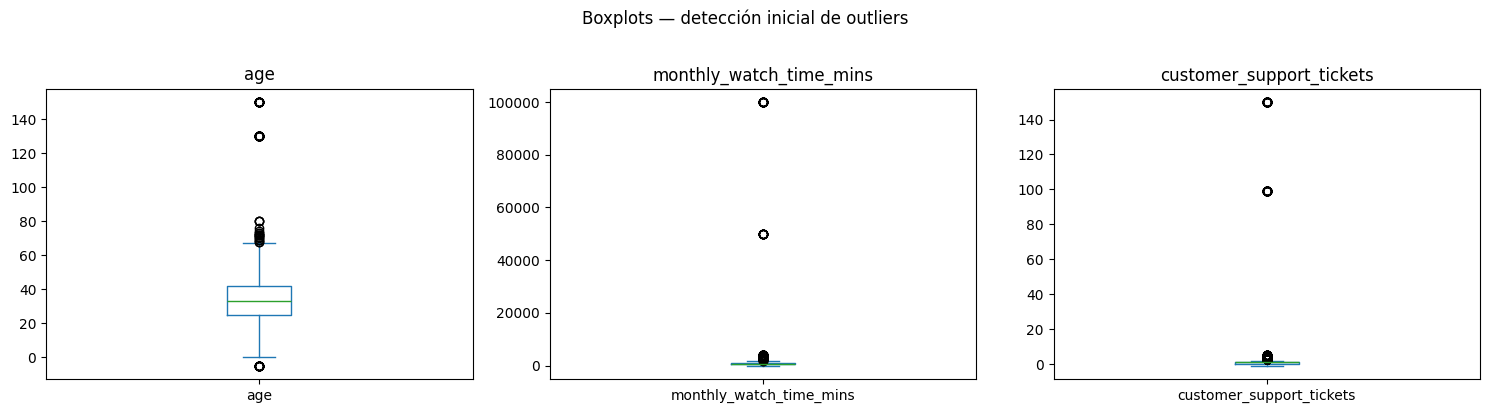

age: min = -5 | max = 150
monthly_watch_time_mins: min = -120.0 | max = 99999.0
customer_support_tickets: min = -1 | max = 150


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'monthly_watch_time_mins', 'customer_support_tickets']):
    df[col].dropna().plot(kind='box', ax=ax, title=col)
plt.suptitle('Boxplots — detección inicial de outliers', y=1.02)
plt.tight_layout()
plt.show()

print('age: min =', df['age'].min(), '| max =', df['age'].max())
print('monthly_watch_time_mins: min =', df['monthly_watch_time_mins'].min(), '| max =', df['monthly_watch_time_mins'].max())
print('customer_support_tickets: min =', df['customer_support_tickets'].min(), '| max =', df['customer_support_tickets'].max())

**Observación:** Se detectaron valores claramente erróneos en las tres variables numéricas:
- `age`: valores -5 (imposible) y 130/150 (biológicamente inverosímiles).
- `monthly_watch_time_mins`: valores negativos (-120, -1) y extremos imposibles (50000, 99999).
- `customer_support_tickets`: valor -1 (imposible) y valores 99 y 150 (inverosímiles para soporte mensual).

## 7. Problema en last_login_date

In [10]:
print('Muestra de valores en last_login_date:')
print(df['last_login_date'].dropna().sample(15, random_state=42).values)
slash = df['last_login_date'].dropna().str.contains('/').sum()
print(f'\nRegistros con formato YYYY/MM/DD: {slash}')

Muestra de valores en last_login_date:
['2025-01-01' '2018-10-30' '2024-06-03' '2020-07-03' '2022-08-29'
 '01-16-2023' '2018-09-05' '2022-10-01' '2024-03-27' '2023-03-01'
 '2022-03-09' '2019-07-24' '2018-08-26' '2025-01-28' '2025-03-26']

Registros con formato YYYY/MM/DD: 133


**Observación:** La columna `last_login_date` presenta dos formatos mezclados: `YYYY-MM-DD` y `YYYY/MM/DD`. Además se detectaron fechas futuras posteriores a la fecha actual, que son imposibles para un último login. Ambos problemas deben corregirse antes del análisis.

## 8. Resumen de observaciones iniciales

| Aspecto | Observación |
|---|---|
| Dimensiones | 8160 filas × 8 columnas |
| Duplicados | 126 filas completamente duplicadas |
| Nulos | monthly_watch_time_mins (193), favorite_genre (240), last_login_date (320) |
| Inconsistencias categóricas | subscription_plan (15 variantes), country (26 variantes), favorite_genre (29 variantes) |
| Outliers erróneos | age (-5, 130, 150), watch_time (negativos, 50000/99999), tickets (-1, 99, 150) |
| Fechas | Formatos mixtos y fechas futuras en last_login_date |

Estas observaciones orientan las decisiones de la etapa de calidad y limpieza.